In [1]:
import optuna
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

c:\Users\Steve\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
study = optuna.load_study(
    storage=r"sqlite:///pulse_after_infer.sqlite3",
    study_name="resnet_50_128img_2d_scan",
)

In [3]:
df = study.trials_dataframe()
df = df[df.state == "COMPLETE"]
# df.to_csv("data.csv",index=False)

In [4]:
df = df.explode("user_attrs_top-1")

df = df.reset_index(drop=True)

In [5]:
df = df[["params_x", "params_y", "user_attrs_top-1"]]
df.to_csv("data.csv", index=False)

In [6]:
df_unchanged = df[df["user_attrs_top-1"] == 0.7578125]
df_failed = df[df["user_attrs_top-1"] == -1]
df_one = df[(df["user_attrs_top-1"] != 0.7578125) & (df["user_attrs_top-1"] != -1)]
df_success = df[(df["user_attrs_top-1"] < 0.5) & (df["user_attrs_top-1"] != -1)]

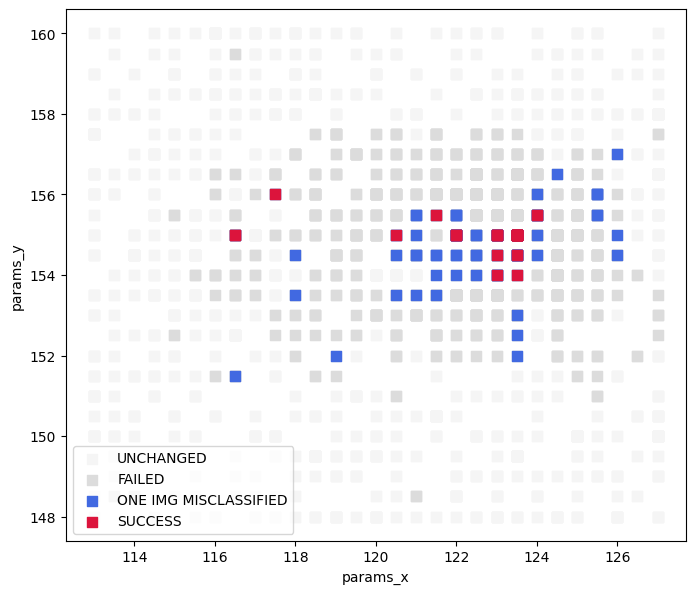

In [7]:
SCALE = 8

fig, ax = plt.subplots(figsize=(SCALE, SCALE))

ax.set_aspect("equal")

param_x = "params_x"
param_y = "params_y"

ax.scatter(
    df_unchanged[param_x],
    df_unchanged[param_y],
    c="whitesmoke",
    label="UNCHANGED",
    s=50,
    marker="s",
)
ax.scatter(
    df_failed[param_x],
    df_failed[param_y],
    c="gainsboro",
    label="FAILED",
    s=50,
    marker="s",
)
ax.scatter(
    df_one[param_x],
    df_one[param_y],
    c="royalblue",
    label="ONE IMG MISCLASSIFIED",
    s=50,
    marker="s",
)

ax.scatter(
    df_success[param_x],
    df_success[param_y],
    c="crimson",
    label="SUCCESS",
    s=50,
    marker="s",
)

ax.set_xlabel(param_x)
ax.set_ylabel(param_y)
ax.legend()

plt.savefig("2d.svg")